# V25 - GNN Supervised Trunk Edge Classifier (AMP Safe)

- GNN을 유지하되 최종 edge를 직접 회귀/유도하지 않고 trunk edge classifier로 학습합니다.
- GT node path를 GT edge mask로 변환하고 weighted BCE + Dice로 학습합니다.
- 시각화는 percentile이 아니라 fixed probability threshold를 사용합니다.
- 후처리 pruning은 GNN 출력 정리용입니다.

In [1]:
import os
!git -C swe3032 pull 2>/dev/null || git clone https://github.com/SKKUAIProjectTeam1/swe3032.git
os.chdir('swe3032')

Updating 46ac715..49b154d
Fast-forward
 collegemap/road_masks/aalto_university_road_mask.npy    | Bin 0 -> 40128 bytes
 collegemap/road_masks/ajou_university_road_mask.npy     | Bin 0 -> 40128 bytes
 .../road_masks/carnegie_mellon_university_road_mask.npy | Bin 0 -> 40128 bytes
 .../chonnam_national_university_road_mask.npy           | Bin 0 -> 40128 bytes
 collegemap/road_masks/chosun_university_road_mask.npy   | Bin 0 -> 40128 bytes
 .../chungbuk_national_university_road_mask.npy          | Bin 0 -> 40128 bytes
 .../chungnam_national_university_road_mask.npy          | Bin 0 -> 40128 bytes
 collegemap/road_masks/dankook_university_road_mask.npy  | Bin 0 -> 40128 bytes
 .../road_masks/dongduk_womens_university_road_mask.npy  | Bin 0 -> 40128 bytes
 collegemap/road_masks/dongguk_university_road_mask.npy  | Bin 0 -> 40128 bytes
 .../road_masks/duksung_womens_university_road_mask.npy  | Bin 0 -> 40128 bytes
 collegemap/road_masks/eth_zurich_road_mask.npy          | Bin 0 -> 40128 bytes
 

In [2]:
# ── OSM 도로 마스크 수집 (이미 있으면 자동 스킵) ──────────────────────────────
import os, glob
_road_dir = 'collegemap/road_masks'
_img_dir  = 'collegemap/images'
os.makedirs(_road_dir, exist_ok=True)

_existing = set(os.path.basename(p).replace('_road_mask.npy','') for p in glob.glob(f'{_road_dir}/*_road_mask.npy'))
_total    = len(glob.glob(f'{_img_dir}/*_building_mask.png'))
print(f'road_masks: {len(_existing)}/{_total}개 완료')

if len(_existing) < _total:
    print('  → 누락분 수집 시작 (osm_road_crawler.py)')
    !python collegemap/osm_road_crawler.py
else:
    print('  → 전부 완료, 스킵')


road_masks: 49/86개 완료
  → 누락분 수집 시작 (osm_road_crawler.py)
Traceback (most recent call last):
  File "/content/swe3032/collegemap/osm_road_crawler.py", line 15, in <module>
    import osmnx as ox
ModuleNotFoundError: No module named 'osmnx'


In [3]:
import glob, os
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from scipy.ndimage import distance_transform_edt, maximum_filter, gaussian_filter
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra as sp_dijkstra

print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

Tesla T4


In [4]:
# ── 설정 ──────────────────────────────────────────────────────────────────────
CODE_VERSION  = 'v25_gnn_supervised_trunk_amp_safe'
print(f'코드 버전: {CODE_VERSION}')
RES           = 100
N             = RES * RES
NODE_DIM      = 8   # building, ridge, dist, x, y, cluster_node, dist_to_cluster, gt_candidate_hint
GAT_HEADS     = 4
EPOCHS        = 220
LR            = 4e-4
WARMUP_EPOCHS = 20
ATTN_DROPOUT  = 0.05
ACCUM_STEPS   = 10
N_GATES       = 2
GATE_MIN_DIST = 14
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# V25 핵심 파라미터
CLUSTER_EPS       = 13.0
ROAD_CLEAR_MIN    = 3.0
ROAD_CLEAR_MAX    = 24.0
RIDGE_FILTER_SIZE = 7
EDGE_THR          = 0.50   # percentile 금지. edge classifier 확률 기준값
PRUNE_ITERS       = 12

IMG_DIR = 'collegemap/images'
TXT_DIR = 'collegemap/txt'
OUT_DIR = 'output'
CKPT    = os.path.join(OUT_DIR, 'v25_gnn_supervised_trunk.pth')
os.makedirs(OUT_DIR, exist_ok=True)


코드 버전: v25_gnn_supervised_trunk_amp_safe


In [5]:
# ── 고정 그래프 토폴로지 ───────────────────────────────────────────────────────
def _build_edges(res):
    edges = []
    for y in range(res):
        for x in range(res):
            s = y * res + x
            for dy in (-1, 0, 1):
                for dx in (-1, 0, 1):
                    if dy == 0 and dx == 0: continue
                    nx_, ny_ = x + dx, y + dy
                    if 0 <= nx_ < res and 0 <= ny_ < res:
                        edges.append((s, ny_ * res + nx_))
    edges += [(i, i) for i in range(res * res)]
    return torch.tensor(edges, dtype=torch.long).t().contiguous()

EDGE_INDEX = _build_edges(RES).to(DEVICE)

_bdy = []
for i in range(10, RES - 10):
    _bdy += [i, (RES-1)*RES + i, i*RES, i*RES + (RES-1)]
BOUNDARY   = sorted(set(_bdy))
BOUNDARY_T = torch.tensor(BOUNDARY, dtype=torch.long).to(DEVICE)

In [6]:
# ── 데이터 로딩 ────────────────────────────────────────────────────────────────
def _find_txt(img_path):
    stem   = os.path.basename(img_path).replace('_building_mask.png', '')
    direct = os.path.join(TXT_DIR, stem + '_building_places.txt')
    if os.path.exists(direct): return direct
    prefix = stem.replace('-', '_').split('_')[0]
    for fn in os.listdir(TXT_DIR):
        if fn.endswith('_building_places.txt') and fn.startswith(prefix):
            return os.path.join(TXT_DIR, fn)
    return None

def _nearest_road_node(cy, cx, is_bld_grid):
    non_bld_yx = np.argwhere(is_bld_grid == 0)
    if len(non_bld_yx) == 0: return int(cy) * RES + int(cx)
    dists = (non_bld_yx[:,0] - cy)**2 + (non_bld_yx[:,1] - cx)**2
    best  = non_bld_yx[np.argmin(dists)]
    return int(best[0]) * RES + int(best[1])

def _make_common_road_ridge(is_bld_grid):
    free = is_bld_grid == 0
    dist = distance_transform_edt(free)
    clear = (dist > ROAD_CLEAR_MIN) & (dist < ROAD_CLEAR_MAX)
    campus_influence = gaussian_filter(is_bld_grid.astype(np.float32), sigma=7.0)
    near_campus = campus_influence > 0.01
    local_max = dist == maximum_filter(dist, size=RIDGE_FILTER_SIZE)
    ridge = free & clear & near_campus & local_max
    ridge_score = gaussian_filter(ridge.astype(np.float32), sigma=1.2)
    if ridge_score.max() < 1e-6:
        band = free & clear & near_campus
        ridge_score = gaussian_filter(band.astype(np.float32), sigma=1.0)
    ridge_score = ridge_score / (ridge_score.max() + 1e-6)
    return ridge_score.astype(np.float32), dist.astype(np.float32)

def _cluster_centers(centers, eps=CLUSTER_EPS):
    n = len(centers); visited = [False] * n; clusters = []
    for i in range(n):
        if visited[i]: continue
        stack = [i]; visited[i] = True; cluster = []
        while stack:
            u = stack.pop(); cluster.append(u); uy, ux = centers[u]
            for v in range(n):
                if visited[v]: continue
                vy, vx = centers[v]
                if ((uy - vy) ** 2 + (ux - vx) ** 2) ** 0.5 <= eps:
                    visited[v] = True; stack.append(v)
        clusters.append(cluster)
    return clusters

def _nearest_ridge_node(cy, cx, is_bld_grid, ridge_grid):
    candidates = np.argwhere((is_bld_grid == 0) & (ridge_grid > 0.05))
    if len(candidates) == 0:
        return _nearest_road_node(cy, cx, is_bld_grid)
    dists = (candidates[:,0] - cy)**2 + (candidates[:,1] - cx)**2
    best = candidates[np.argmin(dists)]
    return int(best[0]) * RES + int(best[1])

def _make_move_graph(is_bld_grid, ridge_grid):
    cost = (1.0 / (ridge_grid.flatten() + 0.12)).astype(np.float32)
    cost[is_bld_grid.flatten() > 0] = 1e6
    y_c = np.repeat(np.arange(RES), RES)
    x_c = np.tile(np.arange(RES), RES)
    rows, cols, vals = [], [], []
    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            if dy == 0 and dx == 0: continue
            ny, nx = y_c + dy, x_c + dx
            valid = (ny >= 0) & (ny < RES) & (nx >= 0) & (nx < RES)
            u = y_c[valid] * RES + x_c[valid]
            v = ny[valid] * RES + nx[valid]
            w = cost[v] * (1.4142 if abs(dy) + abs(dx) == 2 else 1.0)
            rows.append(u); cols.append(v); vals.append(w)
    return csr_matrix((np.concatenate(vals), (np.concatenate(rows), np.concatenate(cols))), shape=(N, N))

def _select_gate_nodes(cluster_node_list, is_bld_grid, ridge_grid):
    """GT에 외부 진입점이 들어가도록 boundary 중 클러스터와 가까운 비건물 노드를 고릅니다."""
    if len(cluster_node_list) == 0: return []
    cy = np.mean([n // RES for n in cluster_node_list])
    cx = np.mean([n % RES for n in cluster_node_list])
    candidates = []
    for node in BOUNDARY:
        y, x = divmod(int(node), RES)
        if is_bld_grid[y, x] > 0: continue
        # 외곽 중 캠퍼스 중심과 가까운 후보. ridge가 있으면 가산점.
        score = ((y - cy) ** 2 + (x - cx) ** 2) ** 0.5 - ridge_grid[y, x] * 8.0
        candidates.append((score, int(node)))
    candidates.sort(key=lambda t: t[0])
    chosen = []
    for _, node in candidates:
        y, x = divmod(node, RES)
        if all(abs(x - (p % RES)) + abs(y - (p // RES)) >= GATE_MIN_DIST for p in chosen):
            chosen.append(node)
        if len(chosen) == N_GATES: break
    return chosen

def _compute_gt_path_nodes(terminals, is_bld_grid, ridge_grid):
    """터미널들을 MST로 묶은 trunk GT node mask를 만듭니다."""
    n_t = len(terminals)
    if n_t <= 1 or n_t > 14:
        return torch.zeros(N, dtype=torch.bool, device=DEVICE)
    graph = _make_move_graph(is_bld_grid, ridge_grid)
    idx = np.array(terminals, dtype=np.int32)
    dist, prev = sp_dijkstra(graph, directed=True, indices=idx, return_predecessors=True)

    in_mst = [False] * n_t; in_mst[0] = True; mst_edges = []
    for _ in range(n_t - 1):
        bc, bi, bj = np.inf, -1, -1
        for i in range(n_t):
            if not in_mst[i]: continue
            for j in range(n_t):
                if in_mst[j]: continue
                d = dist[i, terminals[j]]
                if d < bc:
                    bc, bi, bj = d, i, j
        if bi == -1 or not np.isfinite(bc): break
        in_mst[bj] = True; mst_edges.append((bi, bj))

    path_nodes = set()
    for i, j in mst_edges:
        cur = terminals[j]; src = terminals[i]; guard = 0
        while cur != src and cur >= 0 and guard < N:
            path_nodes.add(cur)
            cur = int(prev[i, cur])
            guard += 1
        path_nodes.add(src)
    gt_mask = torch.zeros(N, dtype=torch.bool, device=DEVICE)
    if path_nodes:
        gt_mask[torch.tensor(list(path_nodes), dtype=torch.long, device=DEVICE)] = True
    return gt_mask

def _make_gt_edge_mask(gt_nodes_mask, bld_mask):
    src, dst = EDGE_INDEX[0], EDGE_INDEX[1]
    non_self = src != dst
    # 둘 다 GT path 위에 있는 edge만 positive. OR로 하면 path 주변 찌꺼기까지 positive가 됨.
    gt_edge = (gt_nodes_mask[src] & gt_nodes_mask[dst] & non_self & (~bld_mask))
    return gt_edge.float()

def _dist_to_nodes_feature(nodes):
    yy = torch.arange(N, device=DEVICE) // RES
    xx = torch.arange(N, device=DEVICE) % RES
    if len(nodes) == 0:
        return torch.ones(N, device=DEVICE)
    feats = []
    for node in nodes:
        y, x = divmod(int(node), RES)
        d = torch.sqrt((yy.float() - y) ** 2 + (xx.float() - x) ** 2)
        feats.append(d)
    dmin = torch.stack(feats, dim=0).min(dim=0).values
    return torch.exp(-dmin / 12.0)

def load_campus(img_path, txt_path):
    img    = Image.open(img_path).convert('L')
    W, H   = img.size
    is_bld = (np.array(img.resize((RES,RES), resample=Image.NEAREST)) > 128).astype(np.float32)

    ridge, dist = _make_common_road_ridge(is_bld)
    dist_n = (dist / (dist.max() + 1e-6)).astype(np.float32)

    ns = {}
    exec(open(txt_path, encoding='utf-8').read(), ns)
    poly = ns['BUILDING_POLY']

    building_ids = list(poly.keys())
    centers = []
    for bid in building_ids:
        pts = poly[bid]
        cy = np.mean([p[1] for p in pts]) * RES / H
        cx = np.mean([p[0] for p in pts]) * RES / W
        centers.append((cy, cx))

    bld_nodes = [_nearest_road_node(cy, cx, is_bld) for cy, cx in centers]
    clusters = _cluster_centers(centers, eps=CLUSTER_EPS)
    cluster_nodes, cluster_groups = [], []
    for cluster in clusters:
        cy = np.mean([centers[i][0] for i in cluster])
        cx = np.mean([centers[i][1] for i in cluster])
        node = _nearest_ridge_node(cy, cx, is_bld, ridge)
        if node not in cluster_nodes:
            cluster_nodes.append(node)
            cluster_groups.append([building_ids[i] for i in cluster])
    if len(cluster_nodes) <= 1 and len(bld_nodes) > 1:
        cluster_nodes = list(dict.fromkeys(bld_nodes))
        cluster_groups = [[bid] for bid in building_ids]

    gate_nodes = _select_gate_nodes(cluster_nodes, is_bld, ridge)
    terminals = list(dict.fromkeys(gate_nodes + cluster_nodes))

    ib_flat  = torch.tensor(is_bld.flatten(), dtype=torch.float32).to(DEVICE)
    src, dst = EDGE_INDEX[0], EDGE_INDEX[1]
    bld_mask = (ib_flat[src] > 0) | (ib_flat[dst] > 0)

    # OSM road GT 우선, 없으면 Dijkstra MST fallback
    slug = os.path.basename(img_path).replace('_building_mask.png', '')
    road_npy = os.path.join('collegemap', 'road_masks', f'{slug}_road_mask.npy')
    if os.path.exists(road_npy):
        road_map = np.load(road_npy)
        road_nodes_mask = torch.tensor(road_map.flatten() > 0.15, dtype=torch.bool, device=DEVICE)
        gt_nodes_mask = road_nodes_mask & (~ib_flat.bool())
        gt_source = 'osm'
    else:
        gt_nodes_mask = _compute_gt_path_nodes(terminals, is_bld, ridge)
        gt_source = 'dijkstra'

    gt_edge_mask = _make_gt_edge_mask(gt_nodes_mask, bld_mask)

    xs = np.tile(np.arange(RES), RES).astype(np.float32) / RES
    ys = np.repeat(np.arange(RES), RES).astype(np.float32) / RES
    cluster_indicator = torch.zeros(N, device=DEVICE)
    if cluster_nodes:
        cluster_indicator[torch.tensor(cluster_nodes, dtype=torch.long, device=DEVICE)] = 1.0
    dist_to_cluster = _dist_to_nodes_feature(cluster_nodes).detach().cpu().numpy().astype(np.float32)
    gt_hint = gt_nodes_mask.float().detach().cpu().numpy().astype(np.float32)

    node_feats = np.stack([
        is_bld.flatten(),
        ridge.flatten(),
        dist_n.flatten(),
        xs,
        ys,
        cluster_indicator.detach().cpu().numpy().astype(np.float32),
        dist_to_cluster,
        gt_hint,
    ], axis=1)

    return {
        'node_feats':     torch.tensor(node_feats, dtype=torch.float32).to(DEVICE),
        'is_building':    ib_flat,
        'bld_mask':       bld_mask,
        'ridge':          torch.tensor(ridge.flatten(), dtype=torch.float32).to(DEVICE),
        'building_nodes': torch.tensor(bld_nodes, dtype=torch.long).to(DEVICE),
        'cluster_nodes':  torch.tensor(cluster_nodes, dtype=torch.long).to(DEVICE),
        'gate_nodes':     torch.tensor(gate_nodes, dtype=torch.long).to(DEVICE),
        'terminal_nodes': torch.tensor(terminals, dtype=torch.long).to(DEVICE),
        'cluster_groups': cluster_groups,
        'gt_nodes_mask':  gt_nodes_mask,
        'gt_edge_mask':   gt_edge_mask,
        'poly': poly,
        'name': os.path.basename(img_path).replace('_building_mask.png',''),
        'gt_source': gt_source,
        'W': W,
        'H': H,
    }

campuses = []
for img_path in sorted(glob.glob(os.path.join(IMG_DIR, '*_building_mask.png'))):
    txt = _find_txt(img_path)
    if txt:
        try:
            campuses.append(load_campus(img_path, txt))
        except Exception as e:
            print(f'skip {os.path.basename(img_path)}: {e}')
print(f'{len(campuses)}개 캠퍼스 로드 완료')
for c in campuses[:3]:
    n_ge = int(c['gt_edge_mask'].sum())
    print(f"{c['name']} [{c['gt_source']}]: clusters={len(c['cluster_nodes'])}, gt_edges={n_ge}")
import random
osm_campuses  = [c for c in campuses if c['gt_source'] == 'osm']
test_campuses = [c for c in campuses if c['gt_source'] == 'dijkstra']

random.seed(42)
random.shuffle(osm_campuses)
n_val = max(1, len(osm_campuses) // 7)  # ~14% val
val_campuses   = osm_campuses[:n_val]
train_campuses = osm_campuses[n_val:]

# test셋: gt_hint(feature 7)와 gt mask 제거 — 모델이 GT를 받으면 안 됨
for c in test_campuses:
    c['node_feats'][:, 7] = 0.
    c['gt_edge_mask'] = torch.zeros_like(c['gt_edge_mask'])
    c['gt_nodes_mask'] = torch.zeros_like(c['gt_nodes_mask'])

print(f'Train: {len(train_campuses)}  Val: {len(val_campuses)}  Test: {len(test_campuses)} (GT 없음)')


86개 캠퍼스 로드 완료
aalto_university [osm]: clusters=3, gt_edges=142
ajou_university [osm]: clusters=3, gt_edges=0
carnegie_mellon_university [osm]: clusters=3, gt_edges=202
Train: 42  Val: 7  Test: 37 (시각화 전용)


In [7]:
# ── 모델: GNN trunk edge classifier ────────────────────────────────────────────
class MHGATLayer(nn.Module):
    def __init__(self, in_dim, out_dim, heads=4, dropout=0.0):
        super().__init__()
        assert out_dim % heads == 0
        self.heads = heads; self.dh = out_dim // heads
        self.W    = nn.Linear(in_dim, out_dim, bias=False)
        self.a_s  = nn.Parameter(torch.empty(heads, self.dh))
        self.a_d  = nn.Parameter(torch.empty(heads, self.dh))
        self.norm = nn.LayerNorm(out_dim)
        self.skip = nn.Linear(in_dim, out_dim, bias=False) if in_dim != out_dim else nn.Identity()
        self.drop = nn.Dropout(dropout)
        nn.init.xavier_uniform_(self.W.weight, gain=1.414)
        nn.init.xavier_normal_(self.a_s.unsqueeze(0)); nn.init.xavier_normal_(self.a_d.unsqueeze(0))

    def forward(self, x, ei):
        n = x.size(0); src, dst = ei[0], ei[1]
        h = self.W(x).view(n, self.heads, self.dh)
        e = F.leaky_relu((h[src]*self.a_s).sum(-1) + (h[dst]*self.a_d).sum(-1), 0.2)
        e_exp = torch.exp(e - e.max())
        denom = torch.zeros(n, self.heads, device=x.device)
        denom.scatter_add_(0, src.unsqueeze(1).expand(-1, self.heads), e_exp)
        alpha = self.drop(e_exp / (denom[src] + 1e-8))
        msg   = alpha.unsqueeze(-1) * h[dst]
        agg   = torch.zeros(n, self.heads, self.dh, device=x.device)
        agg.scatter_add_(0, src[:,None,None].expand_as(msg), msg)
        return self.norm(F.elu(agg.view(n,-1)) + self.skip(x))

class CampusGAT(nn.Module):
    def __init__(self):
        super().__init__()
        self.gat1 = MHGATLayer(NODE_DIM, 64, GAT_HEADS, ATTN_DROPOUT)
        self.gat2 = MHGATLayer(64, 64, GAT_HEADS, ATTN_DROPOUT)
        self.gat3 = MHGATLayer(64, 64, GAT_HEADS, ATTN_DROPOUT)
        # edge classifier: h_s, h_d, |h_s-h_d|, h_s*h_d, raw edge feature 3개
        self.edge_head = nn.Sequential(
            nn.Linear(64*4 + 3, 128), nn.ReLU(), nn.Dropout(0.08),
            nn.Linear(128, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )
        self.gate_head = nn.Linear(64, 1)
        for m in self.modules():
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.zeros_(m.bias)
        nn.init.constant_(self.edge_head[-1].bias, -3.0)
        nn.init.constant_(self.gate_head.bias, -5.0)

    def forward(self, feats, ei, bld_mask):
        h1 = self.gat1(feats, ei)
        h2 = self.gat2(h1, ei)
        h3 = self.gat3(h2, ei)
        src, dst = ei[0], ei[1]
        hs, hd = h3[src], h3[dst]
        raw_edge = torch.stack([
            (feats[src, 1] + feats[dst, 1]) * 0.5,  # ridge score
            (feats[src, 7] + feats[dst, 7]) * 0.5,  # GT candidate hint
            (src != dst).float(),                  # self-loop 구분
        ], dim=1)
        edge_feat = torch.cat([hs, hd, torch.abs(hs-hd), hs*hd, raw_edge], dim=1)
        edge_logits = self.edge_head(edge_feat).squeeze(-1)
        # 건물 통과 edge와 self-loop는 최종 도로 후보에서 제거
        valid = (~bld_mask) & (src != dst)
        ew = torch.sigmoid(edge_logits) * valid.float()
        gs = torch.sigmoid(self.gate_head(h3[BOUNDARY_T]).squeeze(-1))
        # ew: 후처리/시각화/regularization용 확률값
        # edge_logits: AMP-safe BCEWithLogitsLoss 학습용 원본 logit
        return ew, edge_logits, gs

model = CampusGAT().to(DEVICE)
print(f'파라미터: {sum(p.numel() for p in model.parameters()):,}개')


파라미터: 47,490개


In [8]:
# ── 손실 함수: GT trunk edge supervised BCE ───────────────────────────────────
def trunk_bce_loss(edge_logits, gt_edge_mask, valid_mask):
    """edge 단위 trunk classifier loss.
    AMP/autocast 환경에서는 sigmoid 후 BCELoss가 unsafe라서
    원본 logit에 BCEWithLogits를 직접 적용합니다.
    """
    valid = valid_mask.bool()
    if valid.sum() == 0 or gt_edge_mask.sum() == 0:
        return edge_logits.sum() * 0.

    logits = torch.nan_to_num(edge_logits[valid].float(), nan=0., posinf=20., neginf=-20.).clamp(-20., 20.)
    target = gt_edge_mask[valid].float()

    pos = target.sum()
    neg = target.numel() - pos
    pos_weight = torch.clamp(neg / (pos + 1e-6), min=1.0, max=80.0).detach()

    return F.binary_cross_entropy_with_logits(logits, target, pos_weight=pos_weight)

def soft_dice_loss(ew, gt_edge_mask, valid_mask):
    valid = valid_mask.bool()
    pred = ew[valid]
    target = gt_edge_mask[valid].float()
    inter = (pred * target).sum()
    return 1.0 - (2.0 * inter + 1.0) / (pred.sum() + target.sum() + 1.0)

def false_positive_ridge_loss(ew, c):
    """GT가 아닌데 건물 외곽이나 낮은 ridge에 붙는 edge를 억제합니다."""
    src, dst = EDGE_INDEX[0], EDGE_INDEX[1]
    valid = ((src != dst) & (~c['bld_mask'])).bool()
    gt = c['gt_edge_mask'].bool()
    rs = (c['ridge'][src] + c['ridge'][dst]) * 0.5
    fp = valid & (~gt)
    if fp.sum() == 0:
        return ew.sum() * 0.
    # ridge가 낮은 곳의 false positive를 더 강하게 벌점
    return (ew[fp] * (1.0 - rs[fp]).clamp(0.2, 1.0)).mean()

def gate_count_loss(gs):
    return (gs.sum() - N_GATES).pow(2) * 0.2 + (gs * (1.0 - gs)).mean() * 0.02

def loss_terms(ew, edge_logits, gs, c, scale):
    src, dst = EDGE_INDEX[0], EDGE_INDEX[1]
    valid = ((src != dst) & (~c['bld_mask'])).bool()
    bce  = trunk_bce_loss(edge_logits, c['gt_edge_mask'], valid)
    dice = soft_dice_loss(ew, c['gt_edge_mask'], valid)
    fp   = false_positive_ridge_loss(ew, c) * (0.2 + 0.8 * scale)
    sparse = ew[valid].mean() * 0.03
    gate = gate_count_loss(gs)

    with torch.no_grad():
        pred = ew[valid] > EDGE_THR
        gt = c['gt_edge_mask'][valid] > 0
        tp = (pred & gt).sum().float()
        precision = tp / (pred.sum().float() + 1e-6)
        recall = tp / (gt.sum().float() + 1e-6)

    return {
        'bce': bce,
        'dice': dice,
        'fp': fp,
        'sparse': sparse,
        'gate': gate,
        'precision': precision.detach(),
        'recall': recall.detach(),
    }

def loss_fn(ew, edge_logits, gs, c, scale):
    terms = loss_terms(ew, edge_logits, gs, c, scale)
    return terms['bce'] + 0.8 * terms['dice'] + terms['fp'] + terms['sparse'] + terms['gate']


In [9]:
# ── 학습 ──────────────────────────────────────────────────────────────────────
opt    = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sch    = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=5e-6)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
n = len(train_campuses); loss_curve = []; val_curve = []

for ep in range(1, EPOCHS+1):
    model.train(); scale = min(1.0, ep/WARMUP_EPOCHS); total = 0.; opt.zero_grad()
    debug_terms = None

    do_debug = (ep % 10 == 0 or ep == 1)
    acc_terms = None

    for i, c in enumerate(train_campuses):
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            ew, edge_logits, gs = model(c['node_feats'], EDGE_INDEX, c['bld_mask'])
            loss   = loss_fn(ew, edge_logits, gs, c, scale) / n
        if not torch.isfinite(loss):
            print(f'non-finite loss at ep={ep}, campus={c["name"]}, skip'); loss = loss * 0.
        scaler.scale(loss).backward(); total += loss.item() * n

        if do_debug:
            with torch.no_grad():
                terms = {k: float(v.detach().cpu()) for k, v in loss_terms(ew, edge_logits, gs, c, scale).items()}
                if acc_terms is None:
                    acc_terms = terms.copy()
                else:
                    for k in terms: acc_terms[k] += terms[k]

        if (i+1) % ACCUM_STEPS == 0 or (i+1) == n:
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            scaler.step(opt); scaler.update(); opt.zero_grad()
            if torch.cuda.is_available(): torch.cuda.empty_cache()

    sch.step(); loss_curve.append(total/n)

    # val
    model.eval()
    with torch.no_grad():
        val_total = 0.
        for c in val_campuses:
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                ew, edge_logits, gs = model(c['node_feats'], EDGE_INDEX, c['bld_mask'])
                val_total += loss_fn(ew, edge_logits, gs, c, scale).item()
        val_curve.append(val_total / len(val_campuses))

    # 매 에폭 저장: 중간에 중단돼도 마지막 체크포인트 유지
    torch.save({'epoch': ep, 'model': model.state_dict(), 'loss': total/n}, CKPT)

    msg = f'[{ep:4d}/{EPOCHS}] loss={total/n:.4f}  val={val_curve[-1]:.4f}  lr={sch.get_last_lr()[0]:.2e}'
    if acc_terms is not None:
        mean_t = {k: v/n for k, v in acc_terms.items()}
        brief = ' '.join([f'{k}={v:.3f}' for k, v in mean_t.items()])
        msg += '  | ' + brief
    print(msg)

print(f'완료: {CKPT}')

/tmp/ipykernel_11883/1975286641.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
/tmp/ipykernel_11883/1975286641.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_11883/1975286641.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[   1/220] loss=1.0642  val=0.9159  lr=4.00e-04  | bce=nan dice=0.998 fp=0.011 sparse=0.001 gate=0.027 precision=0.000 recall=0.000
[   2/220] loss=1.0505  val=0.9130  lr=4.00e-04
[   3/220] loss=1.0274  val=0.8936  lr=4.00e-04
[   4/220] loss=1.0106  val=0.8931  lr=4.00e-04
[   5/220] loss=0.9965  val=0.8773  lr=3.99e-04
[   6/220] loss=0.9744  val=0.8683  lr=3.99e-04
[   7/220] loss=0.9526  val=0.8521  lr=3.99e-04
[   8/220] loss=0.9223  val=0.8342  lr=3.99e-04
[   9/220] loss=0.8882  val=0.8083  lr=3.98e-04
[  10/220] loss=0.8445  val=0.7740  lr=3.98e-04  | bce=nan dice=0.954 fp=0.003 sparse=0.000 gate=0.000 precision=0.071 recall=0.004
[  11/220] loss=0.7853  val=0.6807  lr=3.98e-04
[  12/220] loss=0.6158  val=0.1926  lr=3.97e-04
[  13/220] loss=0.3345  val=0.0588  lr=3.97e-04
[  14/220] loss=0.1992  val=0.0692  lr=3.96e-04
[  15/220] loss=0.1757  val=0.0450  lr=3.95e-04
[  16/220] loss=0.1216  val=0.0273  lr=3.95e-04
[  17/220] loss=0.1127  val=0.0323  lr=3.94e-04
[  18/220] loss=

체크포인트 로드: epoch=220


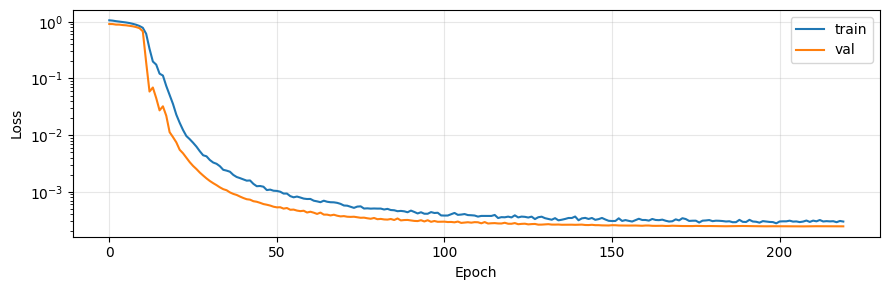

sungkyunkwan_university clusters: 7
C00: ['00', '19', '01', '18', '17']
C01: ['02']
C02: ['03']
C03: ['04', '14', '13', '12', '11', '10', '09', '08', '05']
C04: ['06', '07', '20']
C05: ['15', '16']
C06: ['21', '22']


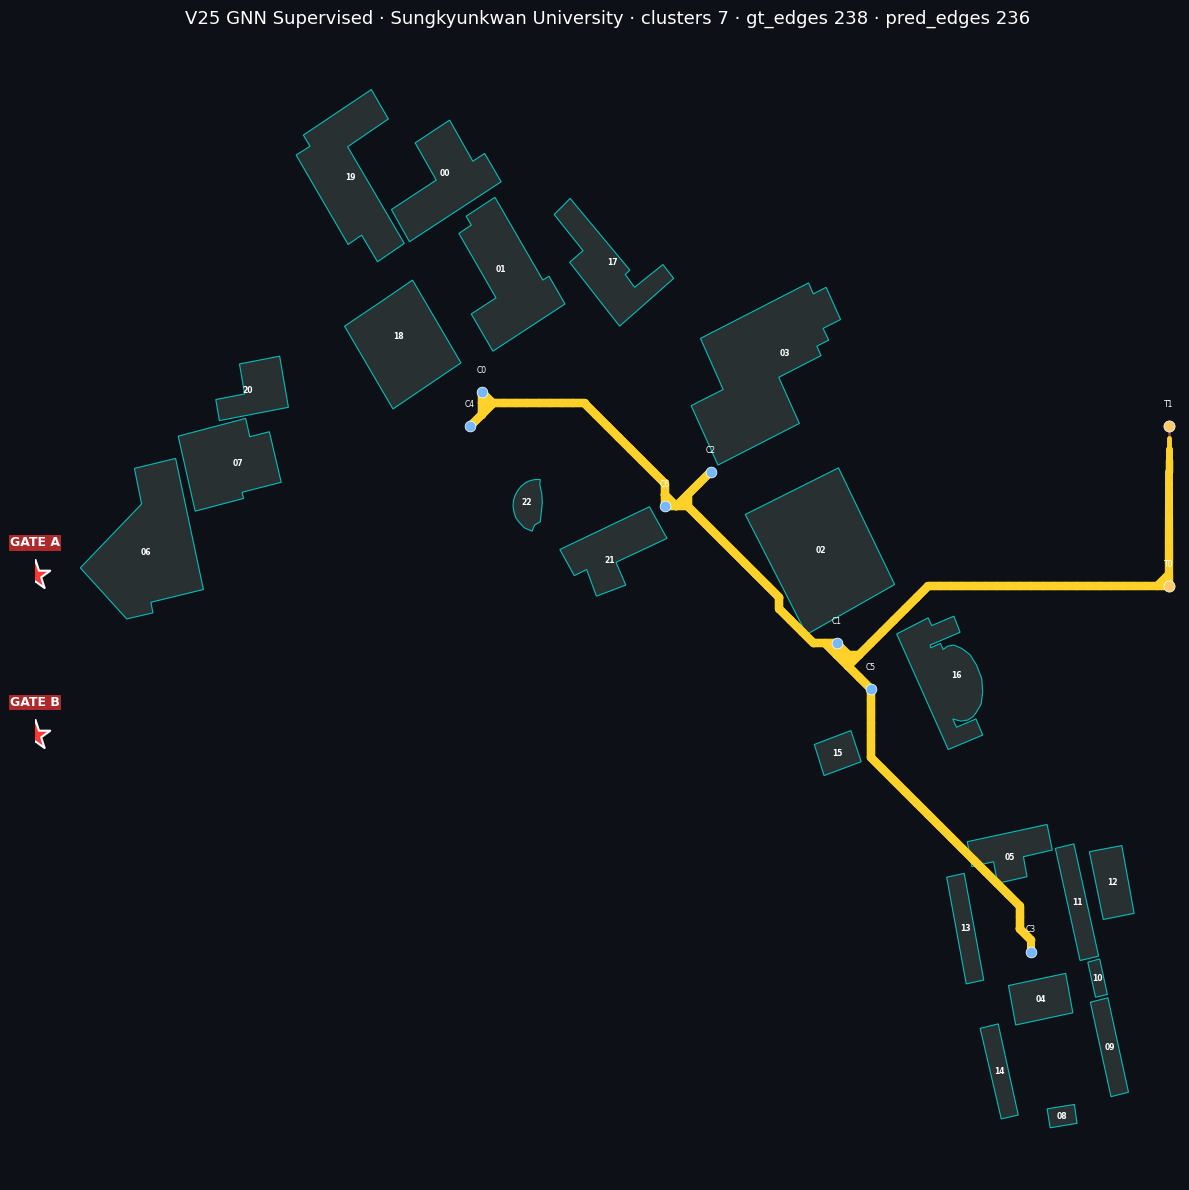

In [10]:
# ── 손실 커브 & 시각화 ─────────────────────────────────────────────────────────
# 학습이 중간에 끊긴 경우 여기서 체크포인트 로드
if os.path.exists(CKPT):
    ck = torch.load(CKPT, map_location=DEVICE)
    state = ck['model'] if isinstance(ck, dict) else ck
    model.load_state_dict(state)
    ep_loaded = ck.get('epoch', '?') if isinstance(ck, dict) else '?'
    print(f'체크포인트 로드: epoch={ep_loaded}')

if loss_curve:
    plt.figure(figsize=(9,3))
    plt.plot(loss_curve, label='train')
    if val_curve: plt.plot(val_curve, label='val')
    plt.yscale('log'); plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

def _draw_node(ax, node, color, label=None, size=55):
    y, x = divmod(int(node), RES)
    ax.scatter(x, y, s=size, c=color, edgecolors='white', linewidths=0.5, zorder=9)
    if label:
        ax.text(x, y-1.5, label, color='white', ha='center', va='bottom', fontsize=5.5, zorder=10)

def _prune_edges(selected, terminals, max_iter=PRUNE_ITERS):
    """GNN 출력 후처리. terminal에 닿지 않는 짧은 가지를 반복 제거합니다."""
    selected = selected.copy()
    ei = EDGE_INDEX.detach().cpu().numpy()
    src, dst = ei[0], ei[1]
    terminal_set = set(int(x) for x in terminals)
    for _ in range(max_iter):
        deg = np.zeros(N, dtype=np.int32)
        for i, keep in enumerate(selected):
            if not keep: continue
            s, d = int(src[i]), int(dst[i])
            if s == d: continue
            deg[s] += 1; deg[d] += 1
        remove = np.zeros_like(selected, dtype=bool)
        changed = False
        for i, keep in enumerate(selected):
            if not keep: continue
            s, d = int(src[i]), int(dst[i])
            if s == d: remove[i] = True; changed = True; continue
            if (deg[s] <= 1 and s not in terminal_set) or (deg[d] <= 1 and d not in terminal_set):
                remove[i] = True; changed = True
        selected[remove] = False
        if not changed: break
    return selected

def _largest_component_edges(selected):
    ei = EDGE_INDEX.detach().cpu().numpy()
    src, dst = ei[0], ei[1]
    adj = {}
    for i, keep in enumerate(selected):
        if not keep: continue
        s, d = int(src[i]), int(dst[i])
        if s == d: continue
        adj.setdefault(s, []).append(d)
        adj.setdefault(d, []).append(s)
    if not adj: return selected
    seen, comps = set(), []
    for node in adj:
        if node in seen: continue
        stack=[node]; seen.add(node); comp=[]
        while stack:
            u=stack.pop(); comp.append(u)
            for v in adj.get(u, []):
                if v not in seen:
                    seen.add(v); stack.append(v)
        comps.append(comp)
    keep_nodes = set(max(comps, key=len))
    out = selected.copy()
    for i, keep in enumerate(selected):
        if not keep: continue
        if int(src[i]) not in keep_nodes or int(dst[i]) not in keep_nodes:
            out[i] = False
    return out

def plot_campus(c, show_clusters=True, show_ridge=False, show_gt=True, use_prune=True):
    model.eval()
    with torch.no_grad():
        ew, edge_logits, gs = model(c['node_feats'], EDGE_INDEX, c['bld_mask'])
    ew_np=ew.cpu().numpy(); gs_np=gs.cpu().numpy(); ei=EDGE_INDEX.cpu(); ib_np=c['is_building'].cpu().numpy()
    W,H = c['W'],c['H']

    order=np.argsort(gs_np)[::-1]; chosen=[]
    for gi in order:
        gx=BOUNDARY[gi]%RES; gy=BOUNDARY[gi]//RES
        if all(abs(gx-BOUNDARY[p]%RES)+abs(gy-BOUNDARY[p]//RES)>=GATE_MIN_DIST for p in chosen):
            chosen.append(gi)
        if len(chosen)==N_GATES: break

    fig,ax=plt.subplots(figsize=(12,12)); ax.set_facecolor('#0d1117'); fig.patch.set_facecolor('#0d1117')

    if show_ridge:
        ridge_img = c['ridge'].detach().cpu().numpy().reshape(RES, RES)
        ax.imshow(ridge_img, cmap='gray', alpha=0.22, extent=[0, RES, RES, 0])

    for bid,pts in c['poly'].items():
        sc=[(p[0]*RES/W,p[1]*RES/H) for p in pts]
        ax.add_patch(mpatches.Polygon(sc,closed=True,facecolor='#2d3436',edgecolor='#00cec9',lw=0.8,alpha=0.9))
        ax.text(np.mean([p[0] for p in sc]),np.mean([p[1] for p in sc]),bid,color='white',ha='center',va='center',fontsize=5.5,fontweight='bold')

    # GT edge를 빨간 실선으로 표시
    if show_gt and c['gt_edge_mask'].sum() > 0:
        gt_edge_np = c['gt_edge_mask'].detach().cpu().numpy().astype(bool)
        for i, keep in enumerate(gt_edge_np):
            if not keep: continue
            s,d=ei[0,i].item(),ei[1,i].item()
            y1,x1=divmod(s,RES); y2,x2=divmod(d,RES)
            ax.plot([x1,x2],[y1,y2],color='#ff6b6b',alpha=0.28,lw=2.0,solid_capstyle='round',zorder=3)

    selected = ew_np > EDGE_THR
    if use_prune:
        selected = _largest_component_edges(selected)
        selected = _prune_edges(selected, c['terminal_nodes'].detach().cpu().numpy())
    selected_count = int(selected.sum())
    mxw=max(ew_np[selected].max() if selected.any() else EDGE_THR, EDGE_THR+1e-8)
    for i, keep in enumerate(selected):
        if not keep: continue
        w=ew_np[i]
        s,d=ei[0,i].item(),ei[1,i].item()
        if ib_np[s]>0 or ib_np[d]>0 or s == d: continue
        y1,x1=divmod(s,RES); y2,x2=divmod(d,RES)
        ax.plot([x1,x2],[y1,y2],color='#ffd32a',alpha=0.92,lw=max(1.2, (w-EDGE_THR)/(mxw-EDGE_THR+1e-8)*5+1),solid_capstyle='round',zorder=5)

    if show_clusters:
        for idx, node in enumerate(c['cluster_nodes'].detach().cpu().numpy()):
            _draw_node(ax, node, '#74b9ff', label=f'C{idx}', size=60)
        for idx, node in enumerate(c['gate_nodes'].detach().cpu().numpy()):
            _draw_node(ax, node, '#fdcb6e', label=f'T{idx}', size=65)

    for k,gi in enumerate(chosen):
        node=BOUNDARY[gi]; gx,gy=node%RES,node//RES
        ax.scatter(gx,gy,s=500,c='#ff3838',marker='*',edgecolors='white',lw=1.5,zorder=10)
        ax.text(gx,gy-2.5,f'GATE {chr(65+k)}',color='white',ha='center',fontsize=9,fontweight='bold',bbox=dict(fc='#d63031',alpha=0.8,ec='none',pad=1))

    ax.set_xlim(0,RES); ax.set_ylim(RES,0); ax.axis('off')
    n_gt = int(c['gt_nodes_mask'].sum())
    n_ge = int(c['gt_edge_mask'].sum())
    ax.set_title(
        f'V25 GNN Supervised · {c["name"].replace("_"," ").title()} · '
        f'clusters {len(c["cluster_nodes"])} · gt_edges {n_ge} · pred_edges {selected_count}',
        color='white', fontsize=13, pad=10
    )
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR,f'v25_gnn_supervised_{c["name"]}.png'),dpi=150,bbox_inches='tight',facecolor='#0d1117')
    plt.show(); plt.close()

def print_clusters(c):
    print(f"{c['name']} clusters: {len(c['cluster_groups'])}")
    for i, group in enumerate(c['cluster_groups']):
        print(f"C{i:02d}: {group}")

TARGET = 'sungkyunkwan_university'
target = next((c for c in campuses if TARGET in c['name']), None)
if target:
    print_clusters(target)
    plot_campus(target, show_clusters=True, show_ridge=False, show_gt=True, use_prune=True)
